In [41]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# --- Configuration & Constants ---
CLASS_NAMES = ["Deep", "Intermediate", "Light"]
CONCENTRATIONS = {"Deep": "2.00%", "Intermediate": "1.75%", "Light": "1.50%"}
SPECTROGRAMS_DIR = "Spectrograms"
DATASET_LABELS = {
    "0002": 0,
    "0003": 1,
    "0004": 2
}

# --- Data Loader Function ---
def load_precomputed_data(base_dir=SPECTROGRAMS_DIR):
    X, y = [], []
    
    for dataset_id, label in DATASET_LABELS.items():
        ds_path = os.path.join(base_dir, dataset_id)
        if not os.path.exists(ds_path):
            print(f"⚠️ Folder missing: {ds_path}")
            continue
            
        print(f"Loading dataset {dataset_id}...")
        files = os.listdir(ds_path)
        
        channels = set()
        trials = set()
        for f in files:
            if f.startswith("channel_") and f.endswith(".npy"):
                parts = f.replace(".npy", "").split("_")
                channels.add(int(parts[1]))
                trials.add(int(parts[3]))
                
        sorted_channels = sorted(list(channels))
        sorted_trials = sorted(list(trials))
        
        if not sorted_trials:
            continue
            
        print(f"   Found {len(sorted_trials)} trials across {len(sorted_channels)} channels.")
        
        for trial in sorted_trials:
            trial_channels = []
            expected_shape = None
            
            for ch in sorted_channels:
                file_path = os.path.join(ds_path, f"channel_{ch}_trial_{trial}.npy")
                spec = np.load(file_path)
                
                if expected_shape is None:
                    expected_shape = spec.shape
                elif spec.shape != expected_shape:
                    raise ValueError(f"Shape mismatch in {dataset_id} at channel {ch}, trial {trial}")
                    
                trial_channels.append(spec)
            
            trial_tensor = np.stack(trial_channels, axis=-1)
            X.append(trial_tensor)
            y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)
    print(f"\nFinal tensor shape X: {X.shape}") 
    print(f"Final labels shape y: {y.shape}")
    return X, y

# --- 1. Load the saved model ---
model = tf.keras.models.load_model("cnn_augmentation_step0.9.h5", compile=False)

# --- 2. Create the gradient model cleanly ---
grad_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[model.get_layer("xai_target_conv").output, model.output]
)

def generate_gradcam(X_sample, target_class_idx):
    """
    X_sample: A single preprocessed trial of shape (77, 14, 30)
    target_class_idx: The actual ground truth class index to compute Grad-CAM for
    """
    if len(X_sample.shape) == 3:
        X_sample = np.expand_dims(X_sample, axis=0) # Add batch dimension -> (1, 77, 14, 30)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(X_sample)
        class_channel = predictions[:, target_class_idx]

    # Extract gradients of the target class score with respect to feature maps
    grads = tape.gradient(class_channel, conv_outputs)

    # Pool gradients across spatial dimensions and batch
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the feature maps by the computed gradients
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Apply ReLU to the heatmap (only keep positive influences)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    
    # Resize heatmap back to original input spatial dimensions (77 frequency bins, 14 time steps)
    heatmap = tf.expand_dims(heatmap, axis=-1) # shape: (H, W, 1)
    heatmap = tf.image.resize(heatmap, (77, 14), method='bilinear')
    heatmap = tf.squeeze(heatmap).numpy()

    return heatmap, predictions[0].numpy()

# --- Execution & Saving Loop ---
if __name__ == "__main__":
    X, y = load_precomputed_data()
    
    if len(X) > 0:
        for target_class_idx, class_name in enumerate(CLASS_NAMES):
            sample_indices = np.where(y == target_class_idx)[0]
            if len(sample_indices) == 0:
                continue
            
            idx = sample_indices[0]
            x_sample = X[idx]
            
            # Generate Grad-CAM specifically for the actual true class
            heatmap, preds = generate_gradcam(x_sample, target_class_idx)
            
            # Plot and save with physical axes (Time: 0 to 2.0s, Frequency: 0 to 300 Hz)
            plt.figure(figsize=(8, 6))
            background_spec = np.mean(x_sample, axis=-1)
            
            # extent=[xmin, xmax, ymin, ymax] -> Time [0, 2.0] seconds, Frequency [0, 300] Hz
            plot_extent = [0.0, 2.0, 0.0, 300.0]
            
            plt.imshow(background_spec, aspect='auto', origin='lower', cmap='gray', extent=plot_extent)
            plt.imshow(heatmap, aspect='auto', origin='lower', cmap='jet', alpha=0.5, extent=plot_extent)
            
            plt.colorbar(label="Grad-CAM Intensity")
            concentration = CONCENTRATIONS[class_name]
            plt.title(f"Grad-CAM Attribution: {class_name} Anesthesia ({concentration})")
            plt.xlabel("Time (s)")
            plt.ylabel("Frequency (Hz)")
            plt.tight_layout()
            
            filename = f"GradCAM_{class_name}.png"
            plt.savefig(filename, dpi=300)
            plt.close()
            print(f"Saved visualization with physical units: {filename}")
    else:
        print("❌ No data found to process.")

Loading dataset 0002...
   Found 119 trials across 30 channels.
Loading dataset 0003...
   Found 119 trials across 30 channels.
Loading dataset 0004...
   Found 119 trials across 30 channels.

Final tensor shape X: (357, 77, 14, 30)
Final labels shape y: (357,)
Saved visualization with physical units: GradCAM_Deep.png
Saved visualization with physical units: GradCAM_Intermediate.png
Saved visualization with physical units: GradCAM_Light.png


--- Grad-CAM Heatmap for Deep State ---


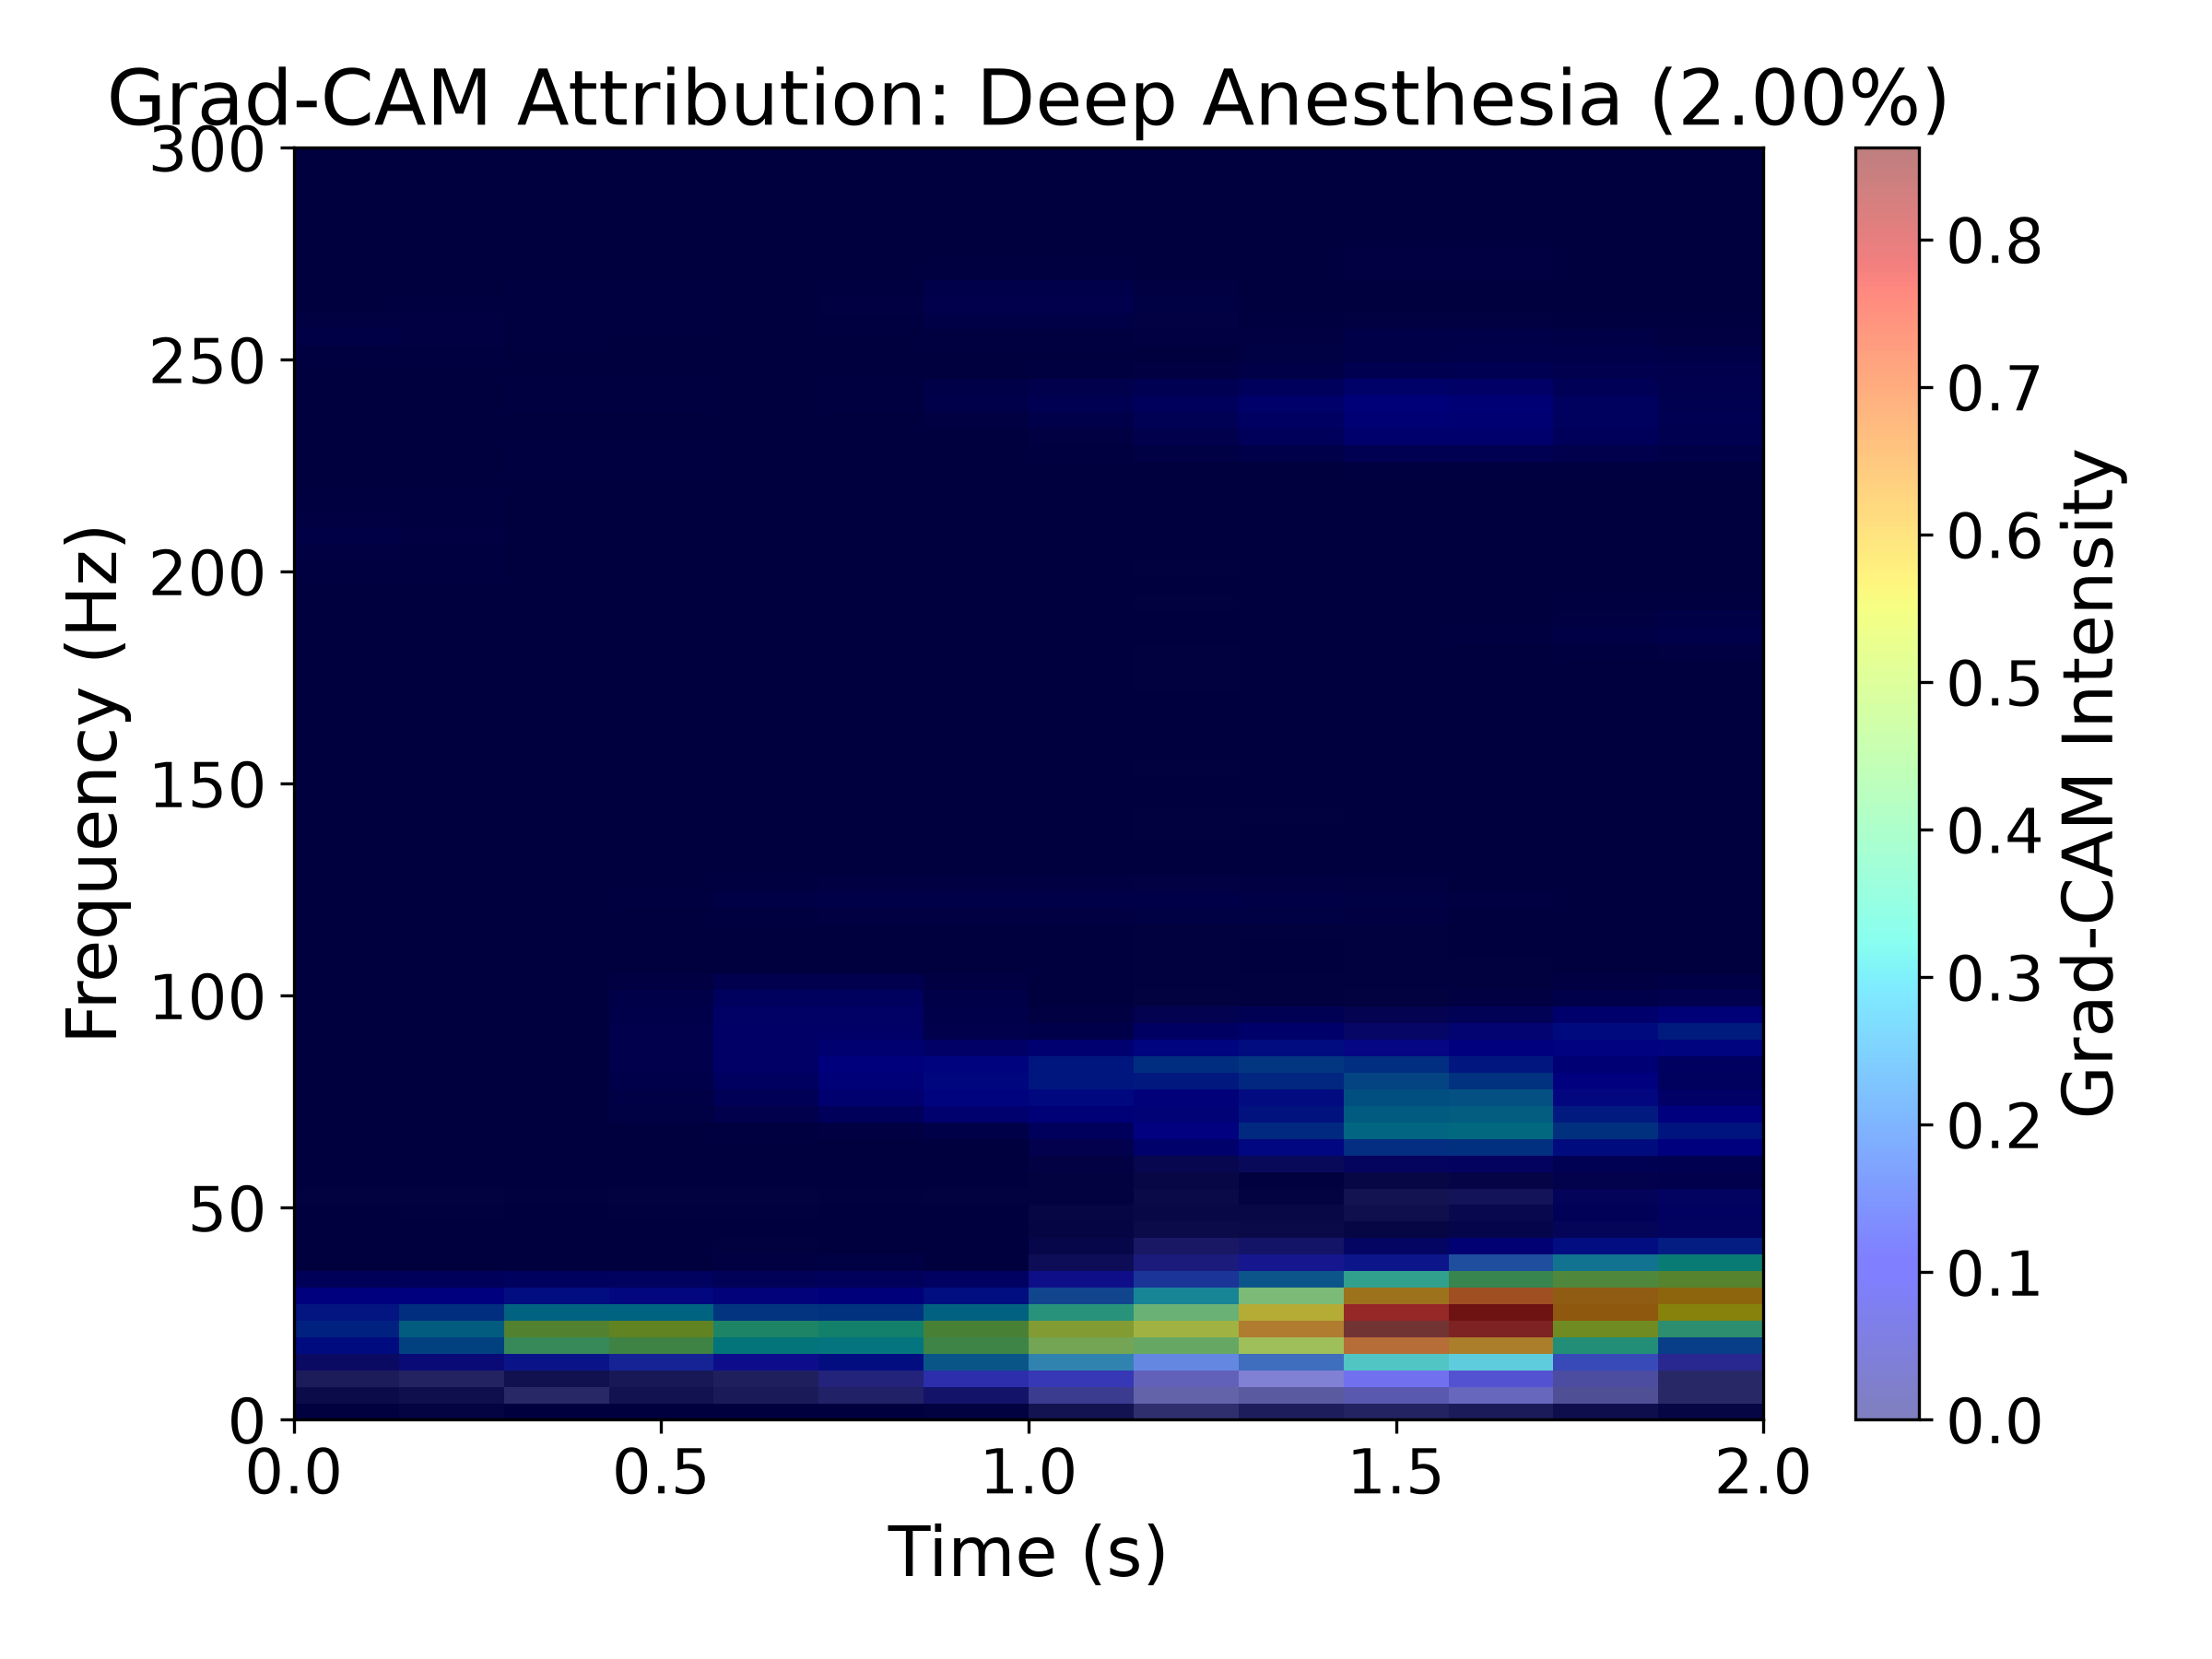

--- Grad-CAM Heatmap for Intermediate State ---


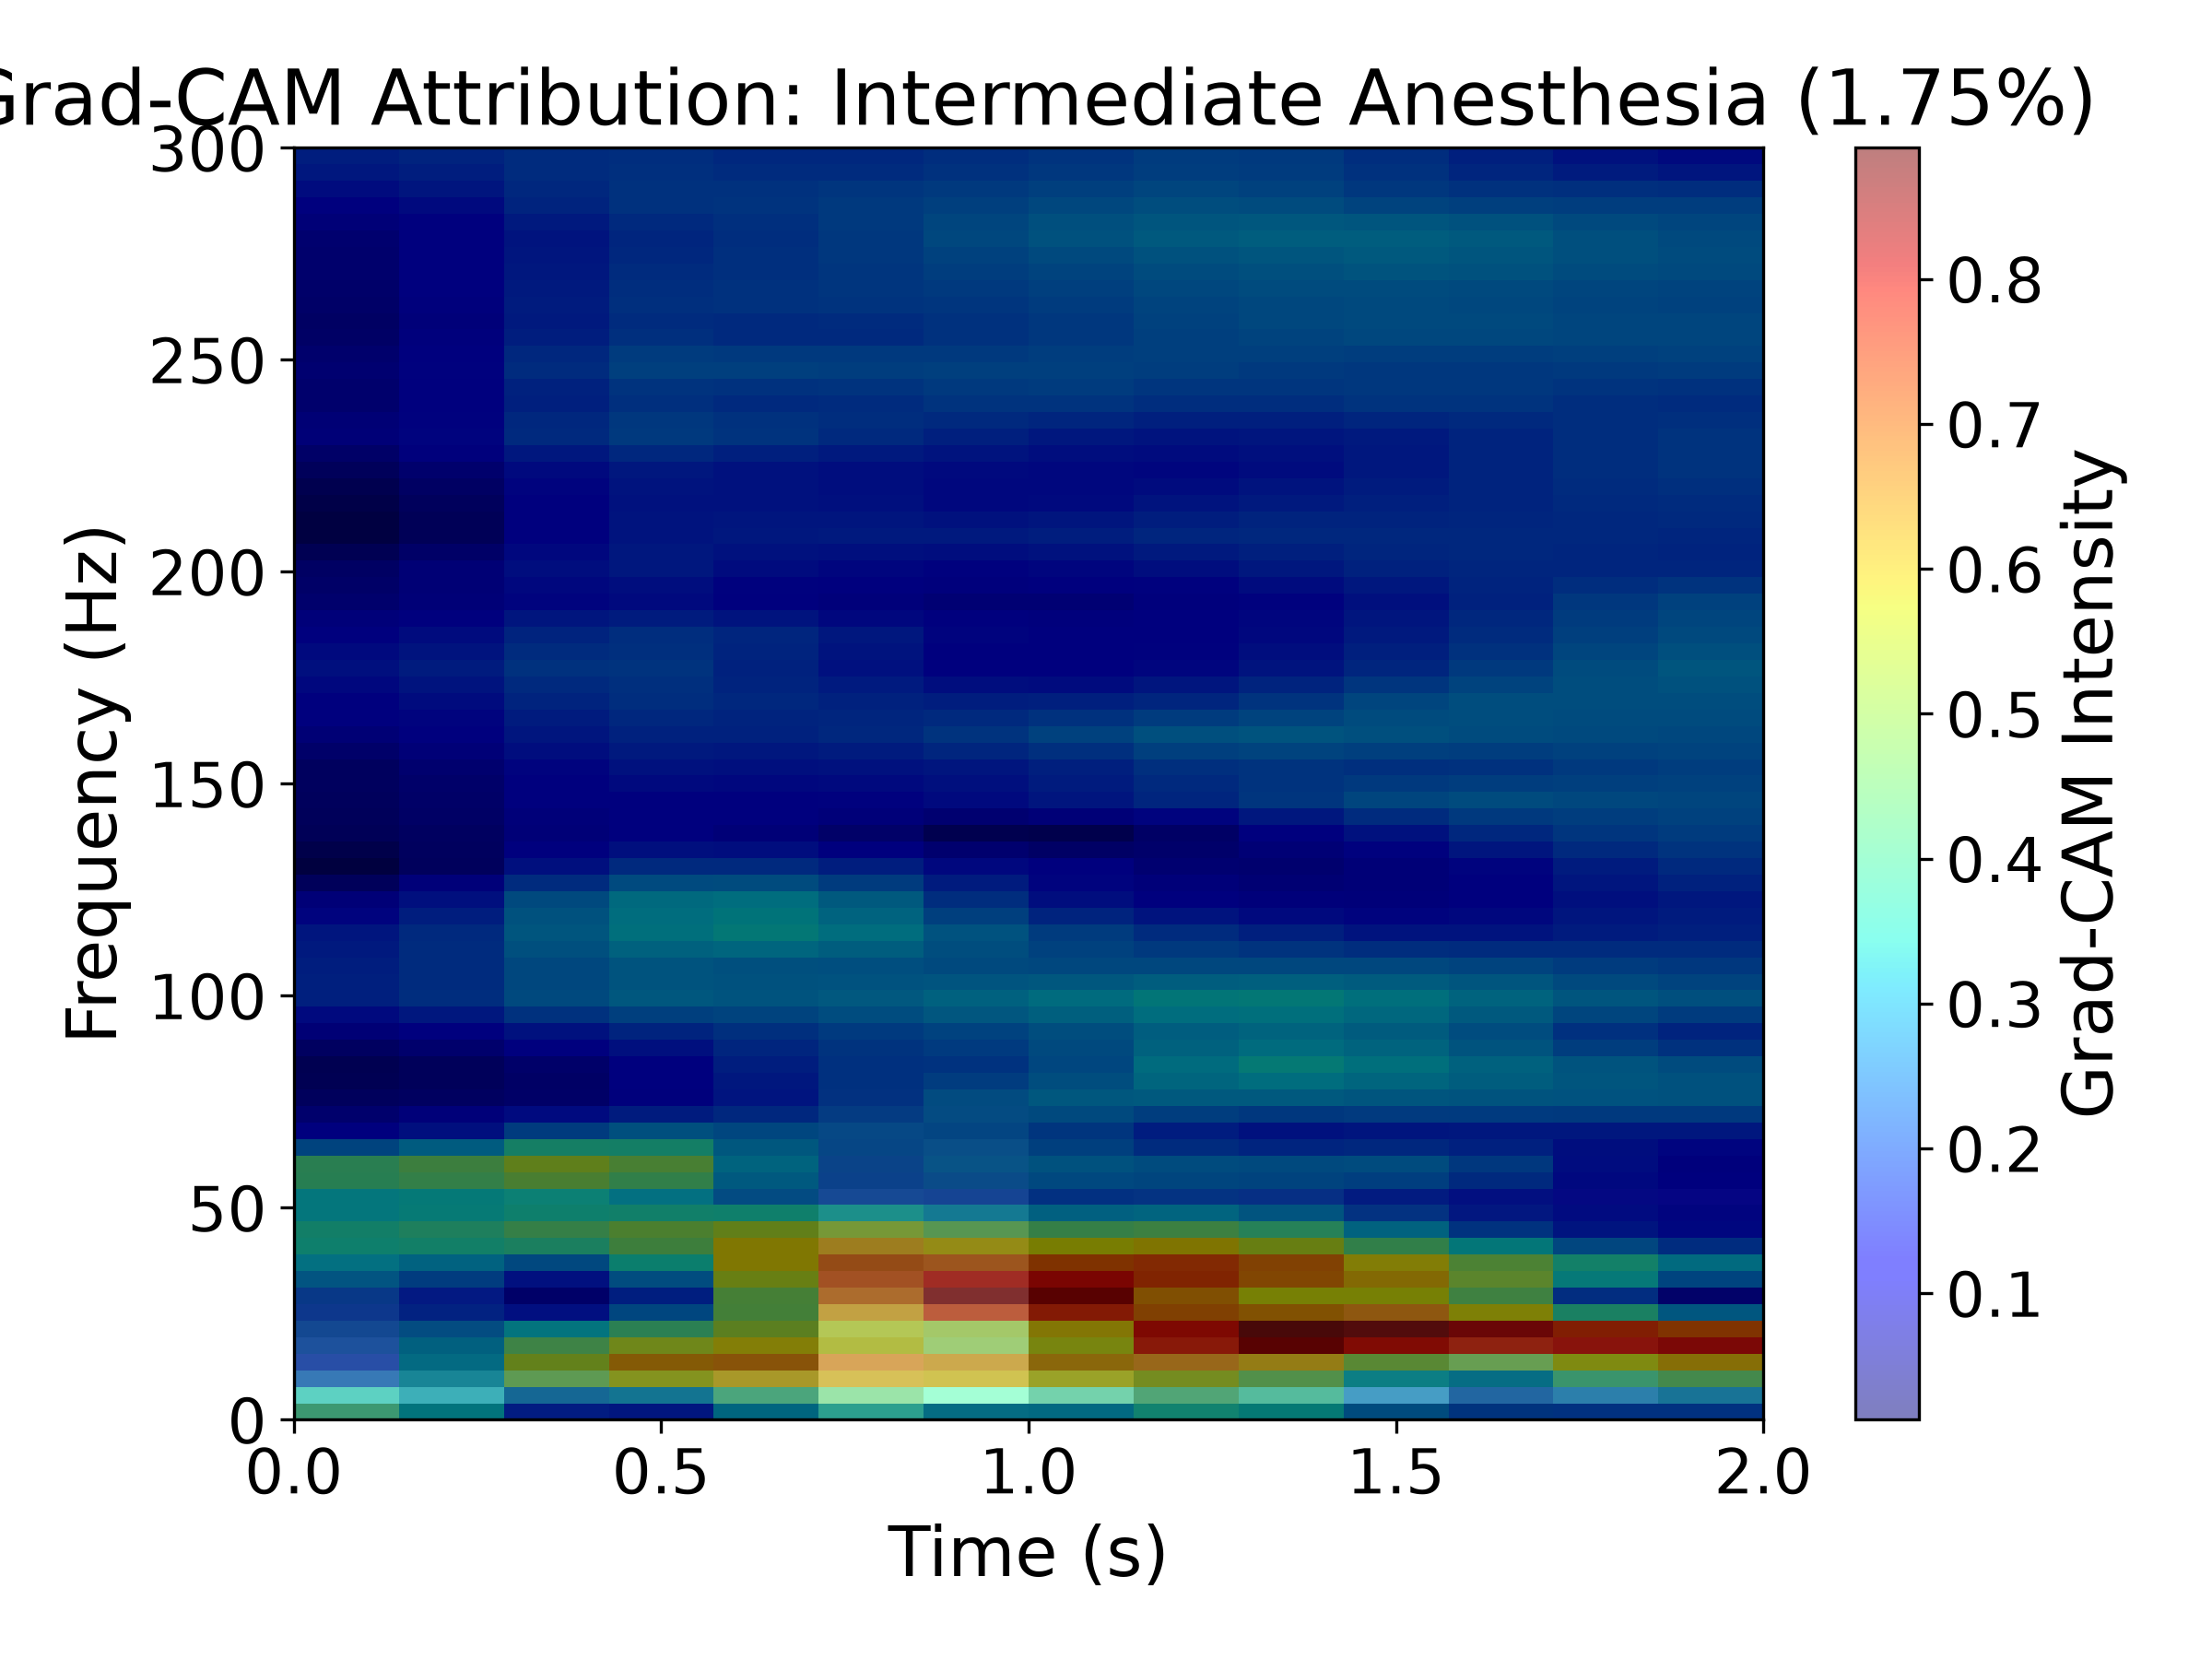

--- Grad-CAM Heatmap for Light State ---


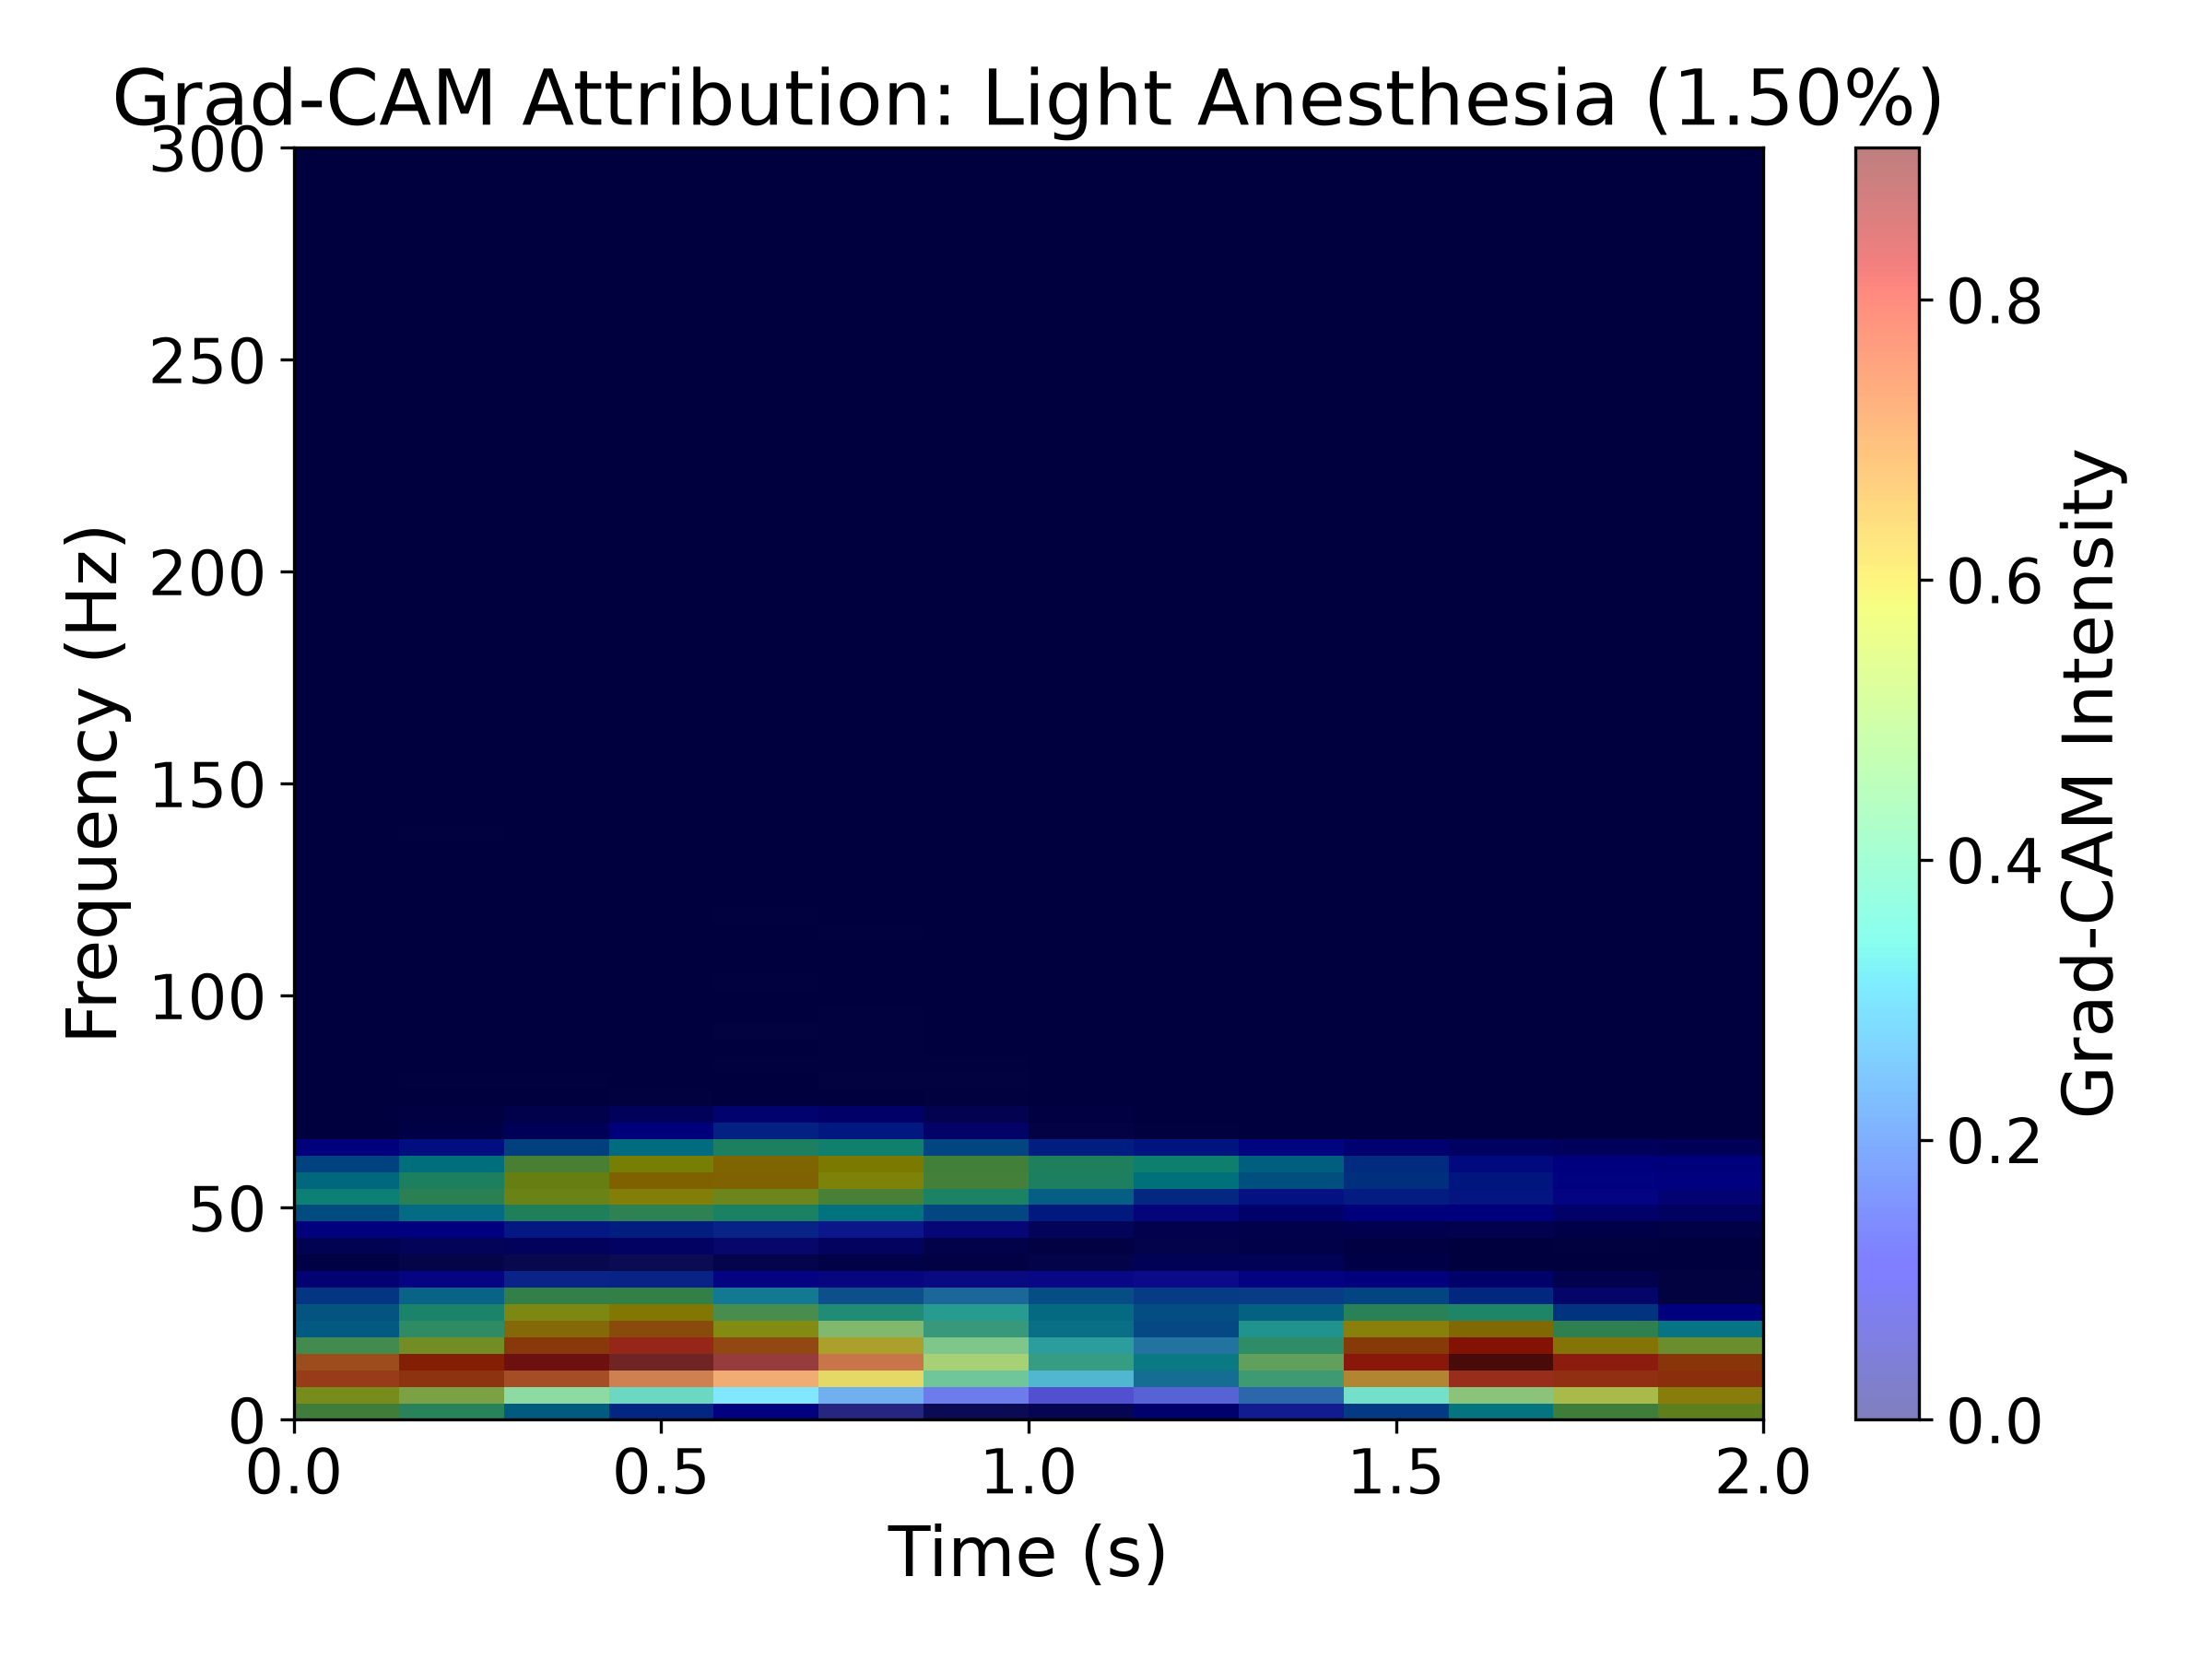

In [42]:
from IPython.display import Image, display

# Loop through the class names and display each saved figure inline
for class_name in CLASS_NAMES:
    filename = f"GradCAM_{class_name}.png"
    if os.path.exists(filename):
        print(f"--- Grad-CAM Heatmap for {class_name} State ---")
        display(Image(filename=filename))

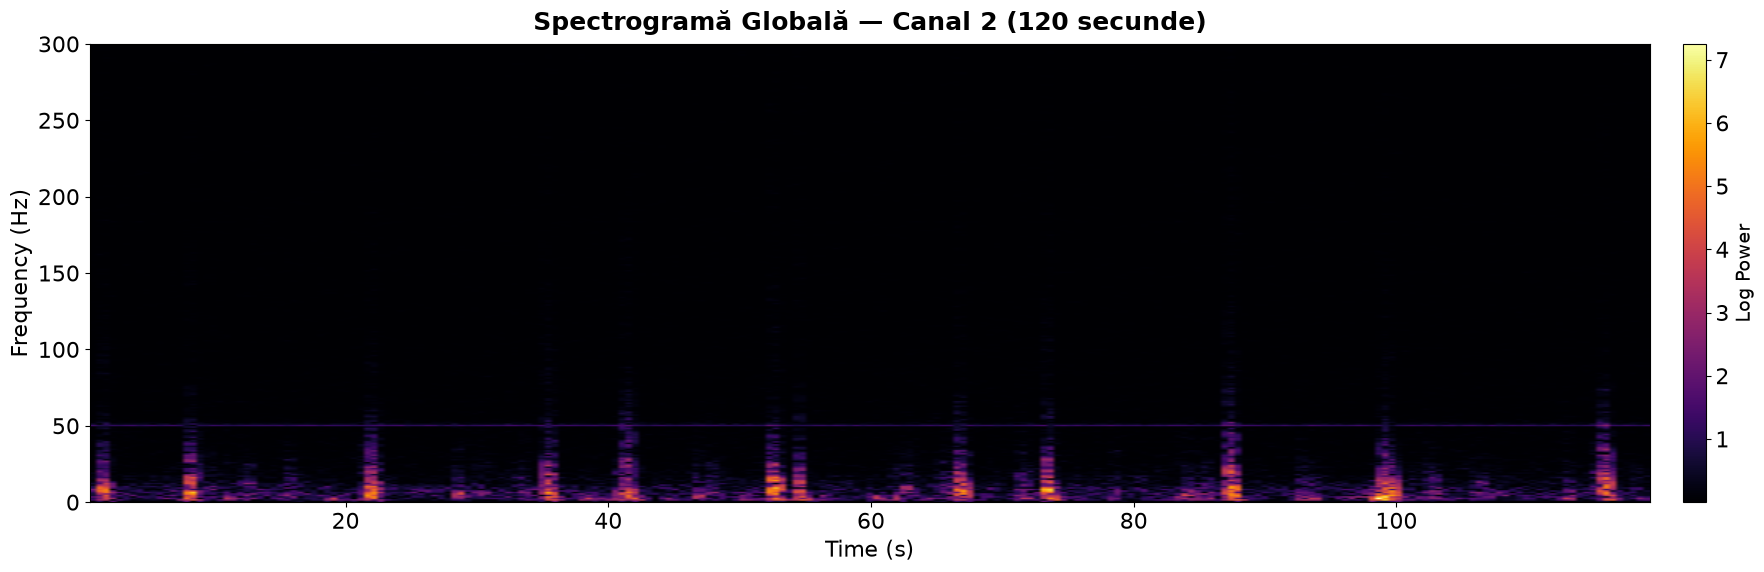

In [43]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
import tensorflow as tf

# --- Setări globale ---
SAMPLE_RATE = 1000
DURATION_SEC = 120
TOTAL_SAMPLES = DURATION_SEC * SAMPLE_RATE
WINDOW_SEC = 2.0
STEP_SEC = 1.0  
WINDOW_SAMPLES = int(WINDOW_SEC * SAMPLE_RATE)
STEP_SAMPLES = int(STEP_SEC * SAMPLE_RATE)
MAX_FREQ = 300

dataset_path = "Anestezie/M014_S001_SRCS3L_25,50,100_0002"  # Deep (label 0)
target_class_idx = 0  

# 1. Încarcă modelul (fără avertismente de compilare)
model = tf.keras.models.load_model("cnn_augmentation_step0.9.h5", compile=False)
grad_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[model.get_layer("xai_target_conv").output, model.output]
)

# 2. Selectează un canal reprezentativ folosind maparea numerică sigură
ch_to_plot = 2
all_files = [f for f in os.listdir(dataset_path) if f.endswith(".bin") and "-Ch" in f]

channel_files = {}
for f in all_files:
    try:
        ch_num = int(f.split("-Ch")[1].split(".")[0])
        channel_files[ch_num] = f
    except (IndexError, ValueError):
        continue

if ch_to_plot not in channel_files:
    raise ValueError(f"Fișierul pentru canalul {ch_to_plot} nu a fost găsit.")

file_path = os.path.join(dataset_path, channel_files[ch_to_plot])
ch_data = np.memmap(file_path, dtype=np.float32, mode='r')[:TOTAL_SAMPLES]

# 3. Generează spectrograma completă pe 120s (pentru fundal)
f, t_axis, Sxx = spectrogram(ch_data, fs=SAMPLE_RATE, nperseg=1024, noverlap=512)
freq_mask = f <= MAX_FREQ
Sxx_filtered = Sxx[freq_mask, :]
Sxx_log = np.log1p(Sxx_filtered)

# 4. Vizualizare globală pe 120 de secunde
plt.figure(figsize=(18, 6))
plot_extent = [t_axis[0], t_axis[-1], f[0], MAX_FREQ]

img = plt.imshow(
    Sxx_log, 
    aspect='auto', 
    origin='lower', 
    extent=plot_extent, 
    cmap='inferno'
)

plt.title(f"Spectrogramă Globală — Canal {ch_to_plot} (120 secunde)", fontsize=18, fontweight='bold', pad=10)
plt.ylabel("Frequency (Hz)", fontsize=16)
plt.xlabel("Time (s)", fontsize=16)

cbar = plt.colorbar(img, fraction=0.03, pad=0.02)
cbar.set_label("Log Power", fontsize=14)

plt.tight_layout()
plt.savefig("Fig_Full_Session_Spectrogram.png", format='png', dpi=300)
plt.show()

In [45]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
import tensorflow as tf

# --- Setări globale pentru text mărit (Publication-Ready) ---
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 22
})

SAMPLE_RATE = 1000
DURATION_SEC = 120
TOTAL_SAMPLES = DURATION_SEC * SAMPLE_RATE
WINDOW_SEC = 2.0
STEP_SEC = 0.5  
WINDOW_SAMPLES = int(WINDOW_SEC * SAMPLE_RATE)
STEP_SAMPLES = int(STEP_SEC * SAMPLE_RATE)
MAX_FREQ = 300

# Dicționarul complet cu cele 3 stări și concentrațiile aferente
DATASETS = {
    "Deep": {"path": "Anestezie/M014_S001_SRCS3L_25,50,100_0002", "label": 0, "conc": "2.00%"},
    "Intermediate": {"path": "Anestezie/M014_S001_SRCS3L_25,50,100_0003", "label": 1, "conc": "1.75%"},
    "Light": {"path": "Anestezie/M014_S001_SRCS3L_25,50,100_0004", "label": 2, "conc": "1.50%"}
}

# 1. Încarcă modelul o singură dată
model = tf.keras.models.load_model("cnn_augmentation_step0.9.h5", compile=False)
grad_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[model.get_layer("xai_target_conv").output, model.output]
)

def compute_trial_spectrogram(trial_matrix, max_freq=300):
    spec_list = []
    for ch_idx in range(trial_matrix.shape[0]):
        f, t, Sxx = spectrogram(trial_matrix[ch_idx, :], fs=SAMPLE_RATE, nperseg=256, noverlap=128)
        freq_mask = f <= max_freq
        spec_list.append(Sxx[freq_mask, :])
    return np.stack(spec_list, axis=-1)

ch_to_plot = 2  # Canal reprezentativ

# 2. Buclă pentru generarea figurilor de 120s pentru fiecare stare de anestezie
for class_name, info in DATASETS.items():
    dataset_path = info["path"]
    target_class_idx = info["label"]
    concentration = info["conc"]
    
    if not os.path.exists(dataset_path):
        print(f"⚠️ Folderul lipsă: {dataset_path}")
        continue
        
    print(f"Procesare sesiune 120s pentru: {class_name} ({concentration})...")
    
    # Identifică fișierele canalelor
    all_files = [f for f in os.listdir(dataset_path) if f.endswith(".bin") and "-Ch" in f]
    channel_files = {}
    for file_name in all_files:
        try:
            ch_num = int(file_name.split("-Ch")[1].split(".")[0])
            channel_files[ch_num] = file_name
        except (IndexError, ValueError):
            continue

    excluded_channels = {1, 22, 33}
    valid_channels = sorted([ch for ch in channel_files.keys() if ch not in excluded_channels])

    # Încarcă datele brute pe 120s
    raw_channels_data = []
    for ch in valid_channels:
        f_path = os.path.join(dataset_path, channel_files[ch])
        ch_data = np.memmap(f_path, dtype=np.float32, mode='r')[:TOTAL_SAMPLES]
        raw_channels_data.append(ch_data)
    raw_matrix = np.array(raw_channels_data)  

    # Fundal spectrogramă 120s
    file_path = os.path.join(dataset_path, channel_files[ch_to_plot])
    ch_data_plot = np.memmap(file_path, dtype=np.float32, mode='r')[:TOTAL_SAMPLES]
    f_spec, t_axis_spec, Sxx_bg = spectrogram(ch_data_plot, fs=SAMPLE_RATE, nperseg=1024, noverlap=512)
    freq_mask_bg = f_spec <= MAX_FREQ
    Sxx_log_bg = np.log1p(Sxx_bg[freq_mask_bg, :])

    # Calcul Grad-CAM temporal pe 120s
    num_freq_bins = 77  
    time_steps_total = int((TOTAL_SAMPLES - WINDOW_SAMPLES) / STEP_SAMPLES) + 1

    gradcam_global = np.zeros((num_freq_bins, time_steps_total))
    counts_global = np.zeros((num_freq_bins, time_steps_total))

    start = 0
    step_idx = 0

    while start + WINDOW_SAMPLES <= TOTAL_SAMPLES and step_idx < time_steps_total:
        end = start + WINDOW_SAMPLES
        trial_data = raw_matrix[:, start:end]
        
        spec = compute_trial_spectrogram(trial_data)
        spec_native = np.log1p(spec).astype(np.float32)
        spec_norm = (spec_native - np.mean(spec_native)) / (np.std(spec_native) + 1e-8)
        X_sample = np.expand_dims(spec_norm, axis=0)  
        
        with tf.GradientTape() as tape:
            conv_outputs, predictions = grad_model(X_sample)
            class_channel = predictions[:, target_class_idx]

        grads = tape.gradient(class_channel, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_outputs = conv_outputs[0]
        heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)
        heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
        
        heatmap = tf.expand_dims(heatmap, axis=-1)
        heatmap = tf.image.resize(heatmap, (num_freq_bins, 14), method='bilinear')
        heatmap = tf.squeeze(heatmap).numpy()
        
        w_width = heatmap.shape[1]
        end_col = min(step_idx + w_width, gradcam_global.shape[1])
        actual_width = end_col - step_idx
        
        gradcam_global[:, step_idx:end_col] += heatmap[:, :actual_width]
        counts_global[:, step_idx:end_col] += 1
        
        start += STEP_SAMPLES
        step_idx += 1

    counts_global[counts_global == 0] = 1
    gradcam_smoothed = gradcam_global / counts_global

    gradcam_smoothed = (gradcam_smoothed - np.min(gradcam_smoothed)) / (np.ptp(gradcam_smoothed) + 1e-8)
    gradcam_masked = np.ma.masked_less(gradcam_smoothed, 0.30)
    t_gradcam_axis = np.linspace(0, DURATION_SEC, gradcam_smoothed.shape[1])

    # Plotare cu elemente text mărite considerabil
    plt.figure(figsize=(18, 7))

    plot_extent = [t_axis_spec[0], t_axis_spec[-1], f_spec[0], MAX_FREQ]
    img_bg = plt.imshow(
        Sxx_log_bg, 
        aspect='auto', 
        origin='lower', 
        extent=plot_extent, 
        cmap='inferno',
        alpha=0.85
    )

    gradcam_extent = [t_gradcam_axis[0], t_gradcam_axis[-1], 0, MAX_FREQ]
    img_gc = plt.imshow(
        gradcam_masked, 
        aspect='auto', 
        origin='lower', 
        extent=gradcam_extent, 
        cmap='jet', 
        alpha=0.65
    )

    plt.title(f"XAI Timeline & Global Spectrogram — {class_name} Anesthesia ({concentration}, Channel {ch_to_plot})", pad=16, fontweight='bold')
    plt.ylabel("Frequency (Hz)")
    plt.xlabel("Time (s)")

    cbar_bg = plt.colorbar(img_bg, ax=plt.gca(), fraction=0.025, pad=0.02)
    cbar_bg.set_label("Log Power (Spectrogram)", fontsize=18)
    cbar_bg.ax.tick_params(labelsize=16)

    plt.tight_layout()
    output_filename = f"Fig_120s_GradCAM_Overlay_{class_name}.png"
    plt.savefig(output_filename, format='png', dpi=300)
    plt.close()
    print(f"✨ Salvat cu succes (text mărit): {output_filename}")

print("\n🎉 Toate hărțile au fost generate cu succes având textul mărit la dimensiuni optime pentru publicare!")

Procesare sesiune 120s pentru: Deep (2.00%)...
✨ Salvat cu succes (text mărit): Fig_120s_GradCAM_Overlay_Deep.png
Procesare sesiune 120s pentru: Intermediate (1.75%)...
✨ Salvat cu succes (text mărit): Fig_120s_GradCAM_Overlay_Intermediate.png
Procesare sesiune 120s pentru: Light (1.50%)...
✨ Salvat cu succes (text mărit): Fig_120s_GradCAM_Overlay_Light.png

🎉 Toate hărțile au fost generate cu succes având textul mărit la dimensiuni optime pentru publicare!


=== XAI Timeline & Spectrogram: Deep Anesthesia ===


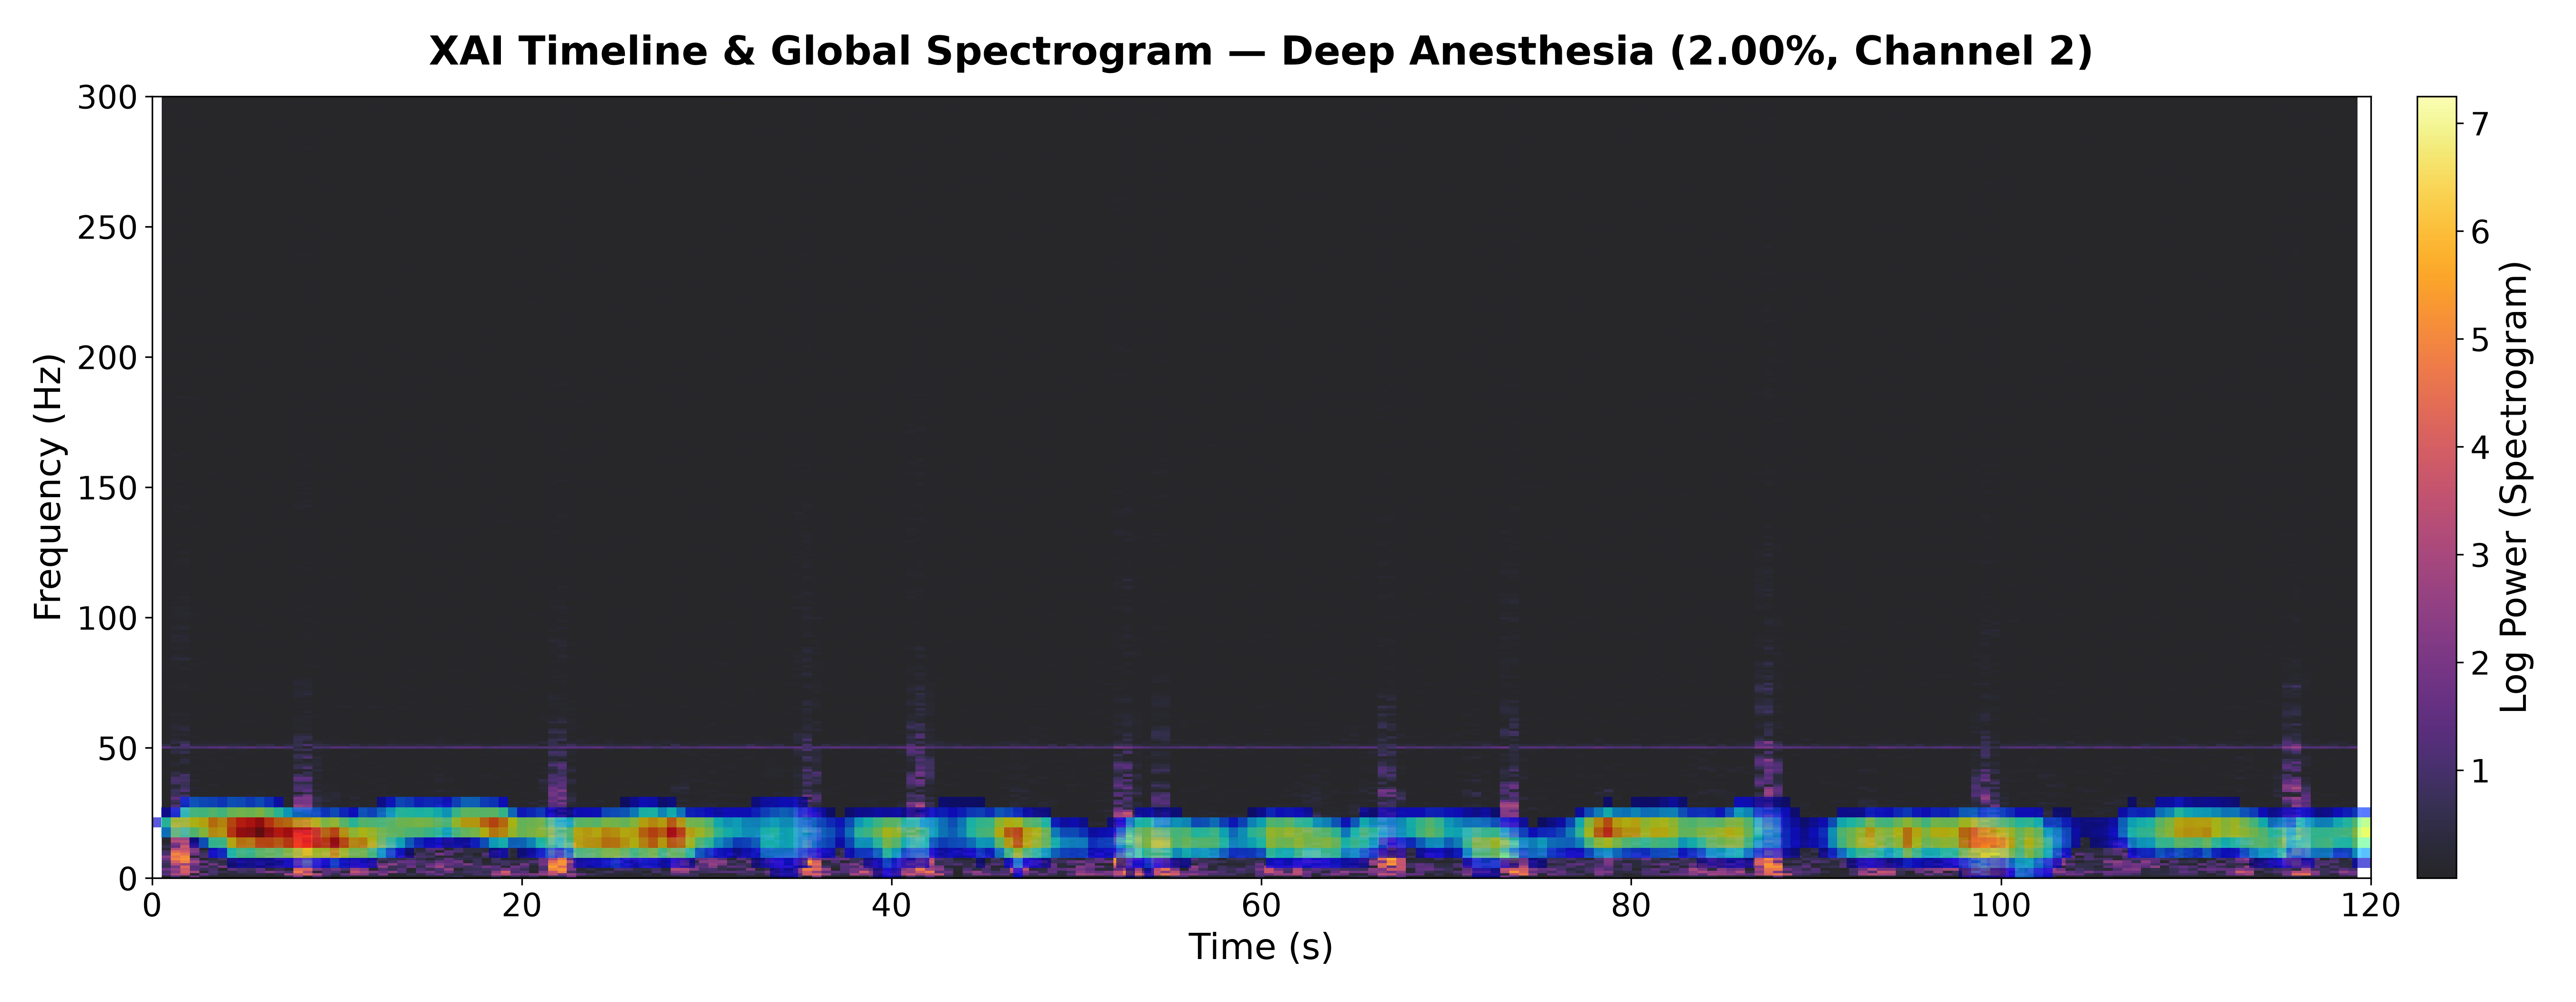

=== XAI Timeline & Spectrogram: Intermediate Anesthesia ===


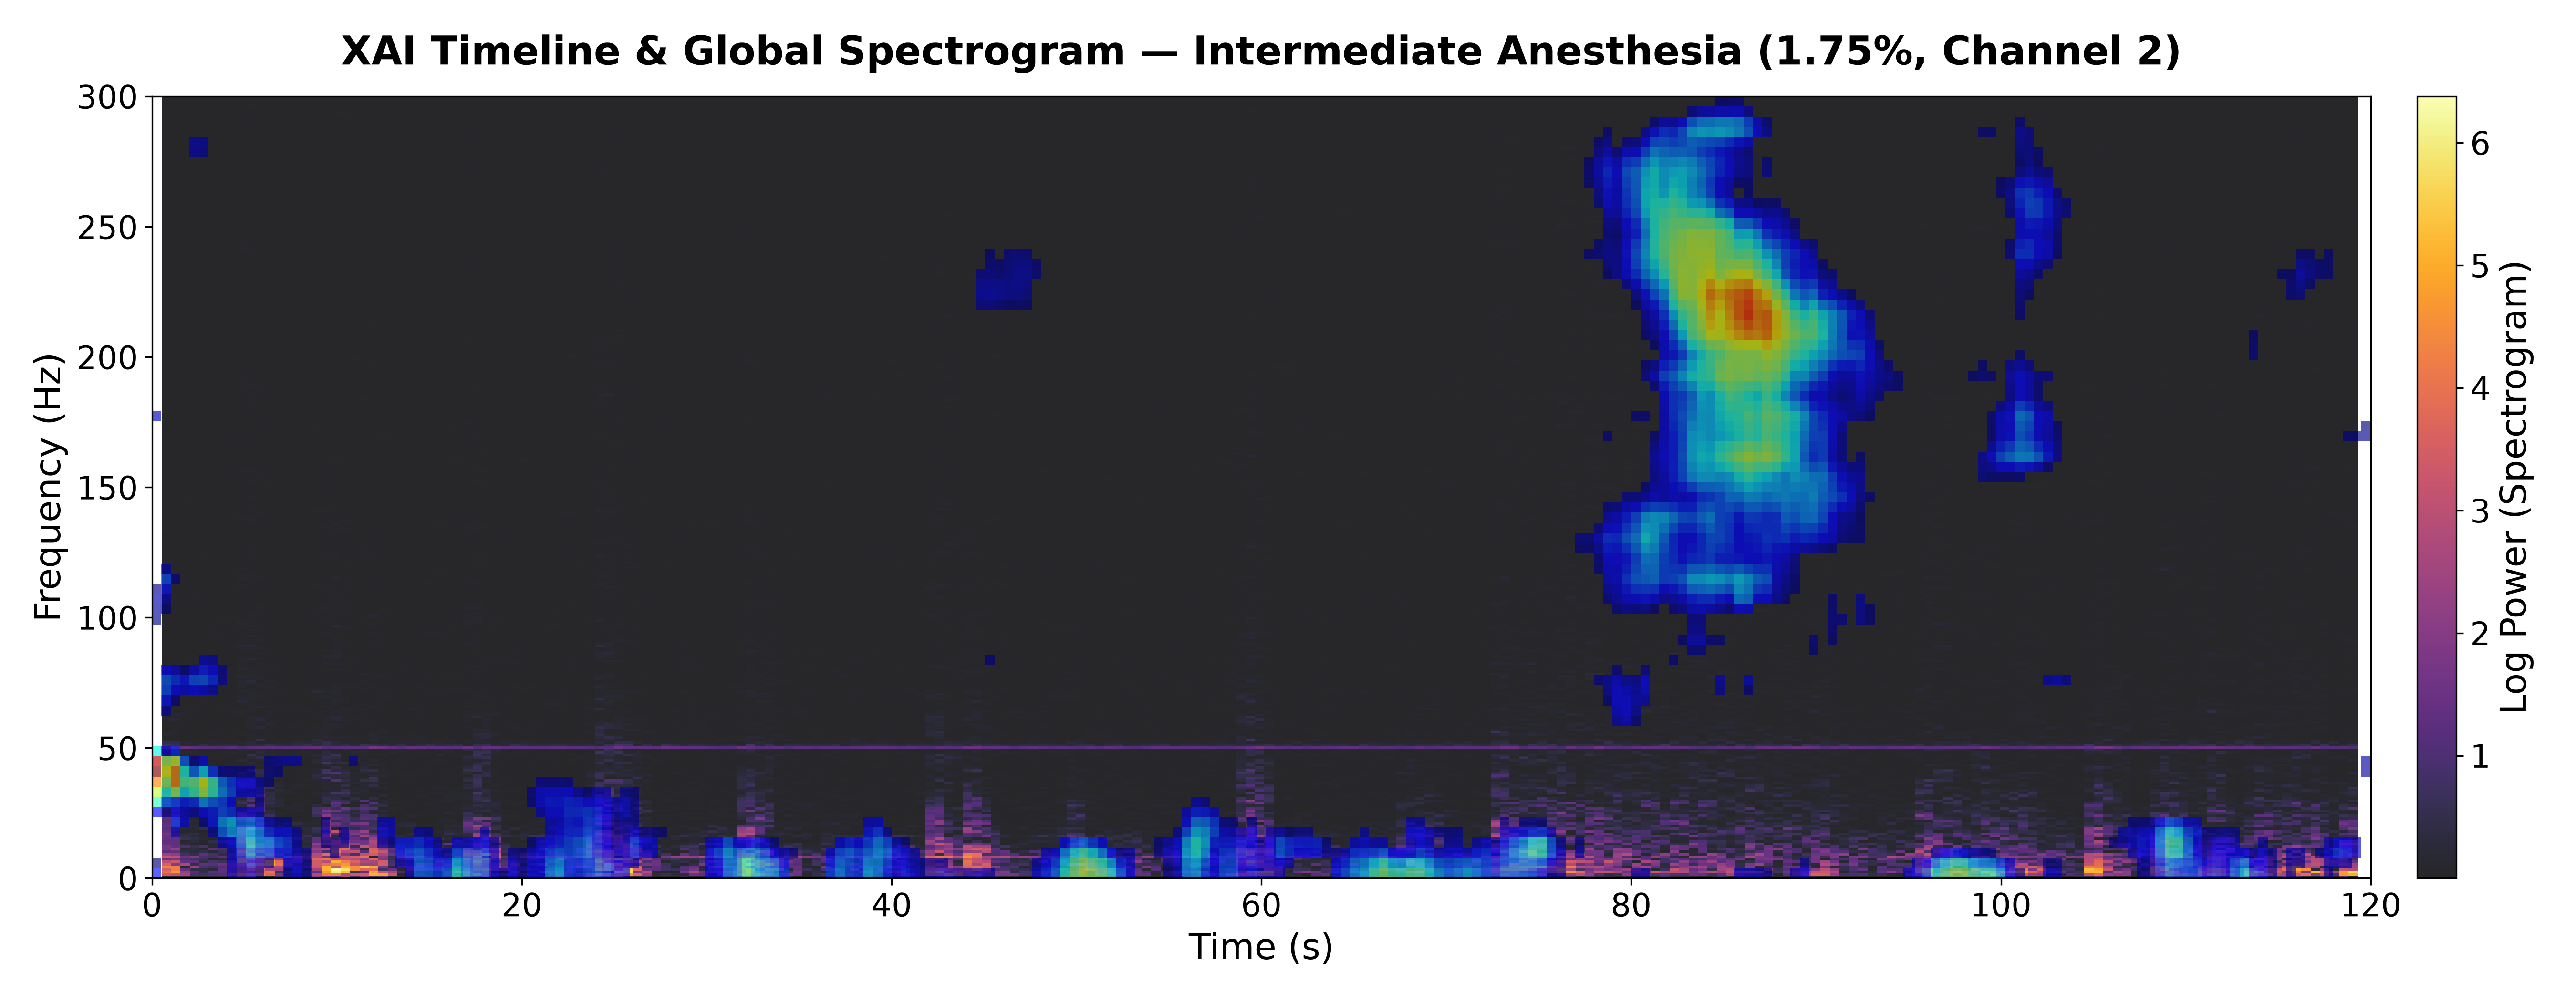

=== XAI Timeline & Spectrogram: Light Anesthesia ===


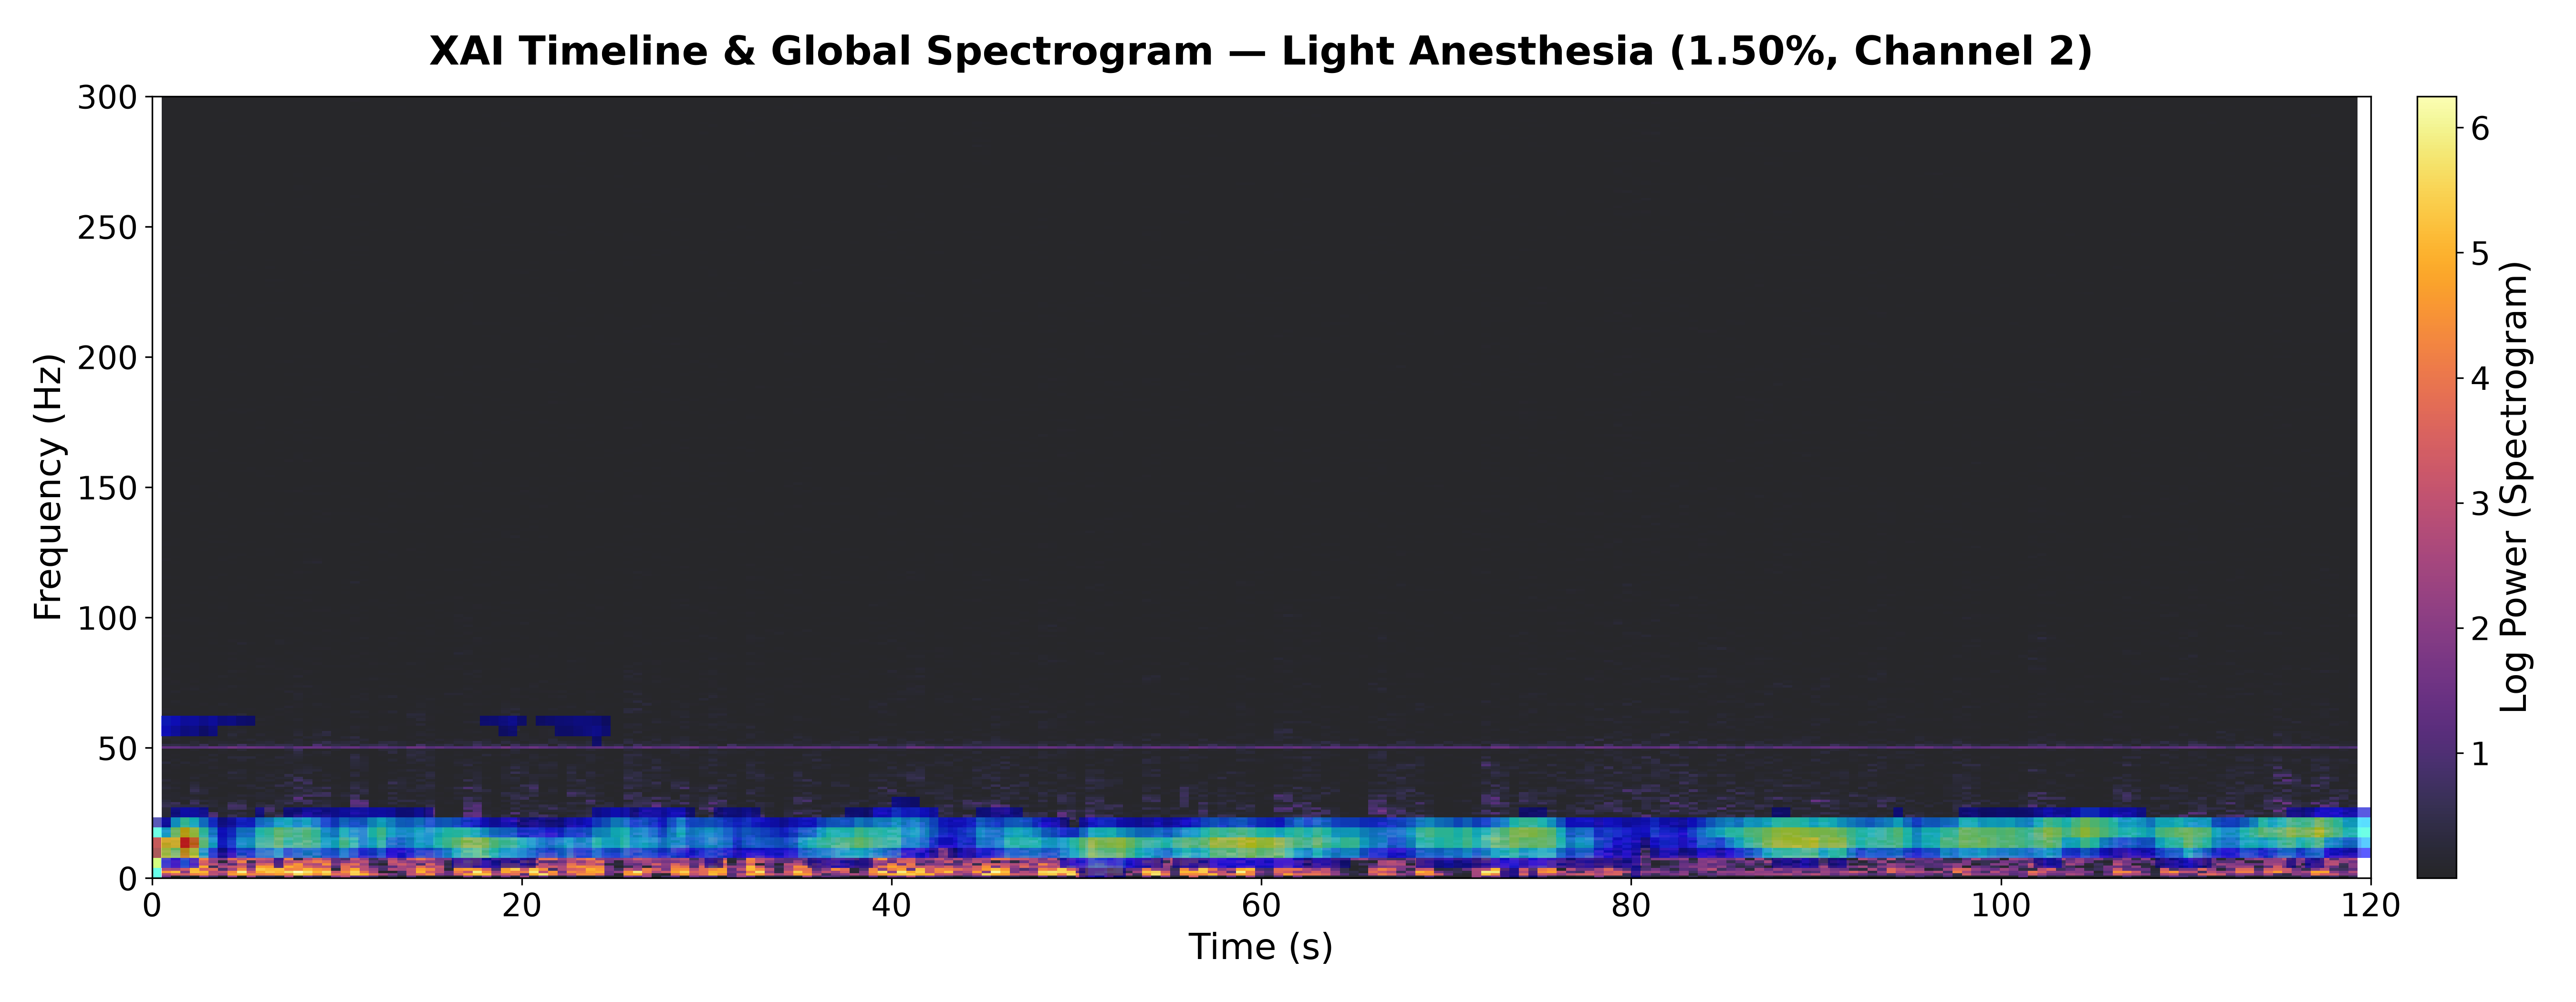

In [46]:
from IPython.display import Image, display

# Afișează inline în notebook toate cele 3 imagini salvate pentru lucrare
for class_name in DATASETS.keys():
    filename = f"Fig_120s_GradCAM_Overlay_{class_name}.png"
    if os.path.exists(filename):
        print(f"=== XAI Timeline & Spectrogram: {class_name} Anesthesia ===")
        display(Image(filename=filename))

✅ S-a găsit fișierul: M014_S001_SRCS3L_25,50,100_0002-Ch023.bin


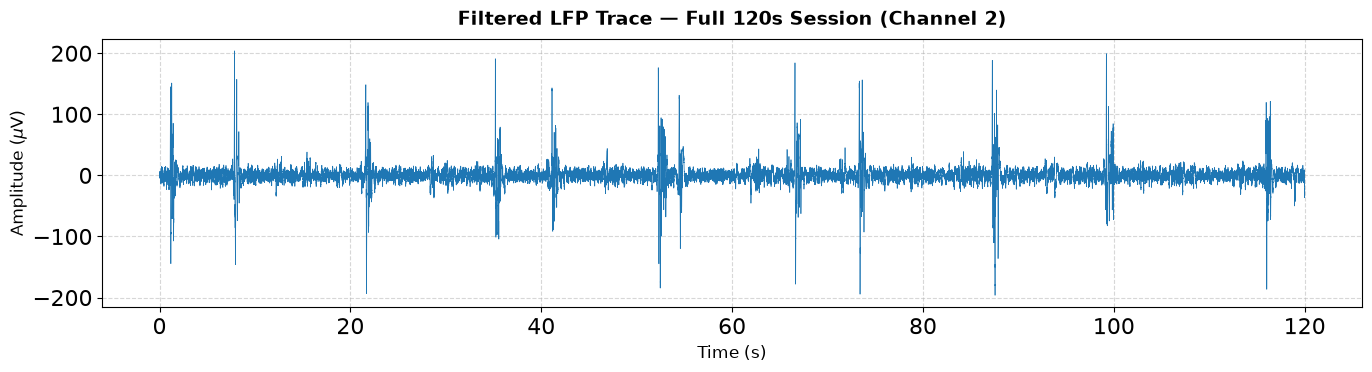

✨ Graficul pe 120 de secunde a fost generat și salvat ca: lfp_trace_120s_ch2.png


In [40]:
import os
import numpy as np
import matplotlib.pyplot as plt

# --- Setări pentru 120 de secunde ---
SAMPLE_RATE = 1000  
DURATION_SEC = 120
TOTAL_SAMPLES = DURATION_SEC * SAMPLE_RATE

dataset_path = "Anestezie/M014_S001_SRCS3L_25,50,100_0002"
target_channel = 2  # Canalul 2 verificat

if os.path.exists(dataset_path):
    all_files = [f for f in os.listdir(dataset_path) if f.endswith(".bin") and "-Ch" in f]
    
    ch_file = None
    for f in all_files:
        if f"-Ch{target_channel}." in f or f"Ch0{target_channel}" in f or f"-Ch{target_channel}" in f:
            ch_file = f
            break
            
    if ch_file:
        f_path = os.path.join(dataset_path, ch_file)
        print(f"✅ S-a găsit fișierul: {ch_file}")
        
        # Încarcă întreg semnalul de 120 secunde
        signal_data = np.memmap(f_path, dtype=np.float32, mode='r')[:TOTAL_SAMPLES]
        time_axis = np.linspace(0, DURATION_SEC, TOTAL_SAMPLES)

        # Plotare pe 120 de secunde
        plt.figure(figsize=(14, 4))
        plt.plot(time_axis, signal_data, color='#1f77b4', linewidth=0.5)
        plt.title(f"Filtered LFP Trace — Full 120s Session (Channel {target_channel})", fontsize=14, fontweight='bold', pad=10)
        plt.xlabel("Time (s)", fontsize=12)
        plt.ylabel(r"Amplitude ($\mu$V)", fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.5)

        plt.tight_layout()
        output_filename = f"lfp_trace_120s_ch{target_channel}.png"
        plt.savefig(output_filename, dpi=300)
        plt.show()
        print(f"✨ Graficul pe 120 de secunde a fost generat și salvat ca: {output_filename}")
    else:
        print(f"⚠️ Nu s-a găsit fișierul pentru canalul {target_channel}.")
else:
    print(f"⚠️ Calea nu există: {dataset_path}")

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.colors import LinearSegmentedColormap

# --- Configuration & Constants ---
CLASS_NAMES = ["Deep", "Intermediate", "Light"]
CONCENTRATIONS = {"Deep": "2.00%", "Intermediate": "1.75%", "Light": "1.50%"}
SPECTROGRAMS_DIR = "Spectrograms"
DATASET_LABELS = {
    "0002": 0,
    "0003": 1,
    "0004": 2
}

# --- Definim colormap-ul custom Verde -> Galben -> Roșu (GYR) ---
gyr_colors = [(0.0, 'green'), (0.5, 'yellow'), (1.0, 'red')]
custom_gyr_cmap = LinearSegmentedColormap.from_list("GreenYellowRed", gyr_colors)

# --- Data Loader Function ---
def load_precomputed_data(base_dir=SPECTROGRAMS_DIR):
    X, y = [], []
    
    for dataset_id, label in DATASET_LABELS.items():
        ds_path = os.path.join(base_dir, dataset_id)
        if not os.path.exists(ds_path):
            print(f"⚠️ Folder missing: {ds_path}")
            continue
            
        print(f"Loading dataset {dataset_id}...")
        files = os.listdir(ds_path)
        
        channels = set()
        trials = set()
        for f in files:
            if f.startswith("channel_") and f.endswith(".npy"):
                parts = f.replace(".npy", "").split("_")
                channels.add(int(parts[1]))
                trials.add(int(parts[3]))
                
        sorted_channels = sorted(list(channels))
        sorted_trials = sorted(list(trials))
        
        if not sorted_trials:
            continue
            
        print(f"   Found {len(sorted_trials)} trials across {len(sorted_channels)} channels.")
        
        for trial in sorted_trials:
            trial_channels = []
            expected_shape = None
            
            for ch in sorted_channels:
                file_path = os.path.join(ds_path, f"channel_{ch}_trial_{trial}.npy")
                spec = np.load(file_path)
                
                if expected_shape is None:
                    expected_shape = spec.shape
                elif spec.shape != expected_shape:
                    raise ValueError(f"Shape mismatch in {dataset_id} at channel {ch}, trial {trial}")
                    
                trial_channels.append(spec)
            
            trial_tensor = np.stack(trial_channels, axis=-1)
            X.append(trial_tensor)
            y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)
    print(f"\nFinal tensor shape X: {X.shape}") 
    print(f"Final labels shape y: {y.shape}")
    return X, y

# --- 1. Load the saved model ---
model = tf.keras.models.load_model("cnn_augmentation_step0.9.h5", compile=False)

# --- 2. Create the gradient model cleanly ---
grad_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[model.get_layer("xai_target_conv").output, model.output]
)

def generate_gradcam(X_sample, target_class_idx):
    if len(X_sample.shape) == 3:
        X_sample = np.expand_dims(X_sample, axis=0)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(X_sample)
        class_channel = predictions[:, target_class_idx]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    
    heatmap = tf.expand_dims(heatmap, axis=-1)
    heatmap = tf.image.resize(heatmap, (77, 14), method='bilinear')
    heatmap = tf.squeeze(heatmap).numpy()

    return heatmap, predictions[0].numpy()

# --- Execution & Grid Plotting Loop ---
# --- Execution & Grid Plotting Loop ---
if __name__ == "__main__":
    X, y = load_precomputed_data()
    
    if len(X) > 0:
        fig, axes = plt.subplots(3, 3, figsize=(15, 12))
        plot_extent = [0.0, 2.0, 0.0, 300.0]
        
        for row_idx, class_name in enumerate(CLASS_NAMES):
            target_class_idx = row_idx  # 0 pentru Deep, 1 pentru Intermediate, 2 pentru Light
            
            sample_indices = np.where(y == target_class_idx)[0]
            if len(sample_indices) == 0:
                continue
            
            idx = sample_indices[0]
            x_sample = X[idx]
            
            heatmap, preds = generate_gradcam(x_sample, target_class_idx)
            background_spec = np.mean(x_sample, axis=-1)
            
            # Normalizăm spectrograma de fundal între 0 și 1 pentru canalul Verde
            bg_min = np.percentile(background_spec, 1)
            bg_max = np.percentile(background_spec, 98)
            bg_norm = np.clip((background_spec - bg_min) / (bg_max - bg_min + 1e-8), 0, 1)
            
            # --- Coloana 1: Doar nuanțe de Verde (Spectrograma pe canalul G) ---
            img_green = np.zeros((*background_spec.shape, 3))
            img_green[..., 1] = bg_norm  # Doar Green
            
            ax1 = axes[row_idx, 0]
            ax1.imshow(img_green, aspect='auto', origin='lower', extent=plot_extent)
            ax1.set_title(f"[{class_name}] Spectrogram (Green)")
            ax1.set_ylabel("Frequency (Hz)")
            if row_idx == 2:
                ax1.set_xlabel("Time (s)")
            
            # --- Coloana 2: Doar nuanțe de Roșu (Grad-CAM pe canalul R) ---
            img_red = np.zeros((*heatmap.shape, 3))
            img_red[..., 0] = heatmap  # Doar Red
            
            ax2 = axes[row_idx, 1]
            ax2.set_facecolor('black')
            ax2.imshow(img_red, aspect='auto', origin='lower', extent=plot_extent)
            ax2.set_title(f"[{class_name}] Grad-CAM Heatmap (Red)")
            ax2.set_ylabel("Frequency (Hz)")
            if row_idx == 2:
                ax2.set_xlabel("Time (s)")
            
            # --- Coloana 3: Overlay RGB (R = Grad-CAM, G = Spectrogramă -> Suprapunerea devine Galbenă) ---
            img_overlay = np.zeros((*heatmap.shape, 3))
            img_overlay[..., 0] = heatmap  # Canalul R (Roșu)
            img_overlay[..., 1] = bg_norm  # Canalul G (Verde)
            # Canalul B rămâne 0. Unde se întâlnesc, R + G = Galben!
            
            ax3 = axes[row_idx, 2]
            ax3.imshow(img_overlay, aspect='auto', origin='lower', extent=plot_extent)
            ax3.set_title(f"[{class_name}] Overlay (Green + Red = Yellow)")
            ax3.set_ylabel("Frequency (Hz)")
            if row_idx == 2:
                ax3.set_xlabel("Time (s)")

        plt.tight_layout()
        output_filename = "gradcam_analysis_all_classes.png"
        plt.savefig(output_filename, dpi=300)
        plt.close()
        print(f"✅ Imaginea RGB (Verde/Roșu/Galben) a fost generată cu succes: {output_filename}")
    else:
        print("❌ Nu s-au găsit date de procesat.")

Loading dataset 0002...
   Found 119 trials across 30 channels.
Loading dataset 0003...
   Found 119 trials across 30 channels.
Loading dataset 0004...
   Found 119 trials across 30 channels.

Final tensor shape X: (357, 77, 14, 30)
Final labels shape y: (357,)
✅ Imaginea RGB (Verde/Roșu/Galben) a fost generată cu succes: gradcam_analysis_all_classes.png
